### Create Gaussian Process around dataset

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType

df = pd.read_csv("../statics/metrics_20_0.csv")
# 2. Initialize and train
rask_gp = GASK(show_figures=False)
rask_gp.init_models(df, density=1.0)

INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
INFO:multiscale:train_gp_models took 202 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [2]:
import numpy as np
%load_ext autoreload
%autoreload 2

rask_gp.predict(ServiceType.QR, "max_tp", {'data_quality': 100, 'cores': 6.0})
rask_gp.predict(ServiceType.QR, "max_tp", {'data_quality': 10000, 'cores': 600.0})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(np.float64(5459.005356479371), np.float64(71525.73249684578))

### Test if the global optimizer converges to a nice result

In [10]:
from agent.components.GaussianProcess import get_empirical_boundaries
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos = slo_lib.get_slo_for_client("experiment-1", "client-1")

empirical_bounds = get_empirical_boundaries(rask_gp.training_data)[ServiceType.QR]
# print(empirical_bounds)

starting_point = [2.0, 400]
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(ServiceType.QR, slos, rask_gp, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[np.float64(5.999999999999998), np.float64(990.0)]

### Test how much the epsilon should be moved each iteration

In [15]:
import numpy as np

s_type = ServiceType.QR

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1, 0.1])
raw_bounds = get_empirical_boundaries(rask_gp.training_data)[s_type]
del raw_bounds['max_tp']

# Store these to use for de-normalization inside the objective
ordered_bounds = list(raw_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos, rask_gp, ordered_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos, rask_gp, ordered_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000008
Eps 0.001: Change in SLO-F is 0.000781
Eps 0.01: Change in SLO-F is 0.007575
Eps 0.05: Change in SLO-F is 0.030700


Iteration 0: Discovered new Elite in bin (np.int64(7), np.int64(3)) with fitness 0.6327
Iteration 100: Discovered new Elite in bin (np.int64(5), np.int64(9)) with fitness 0.5933


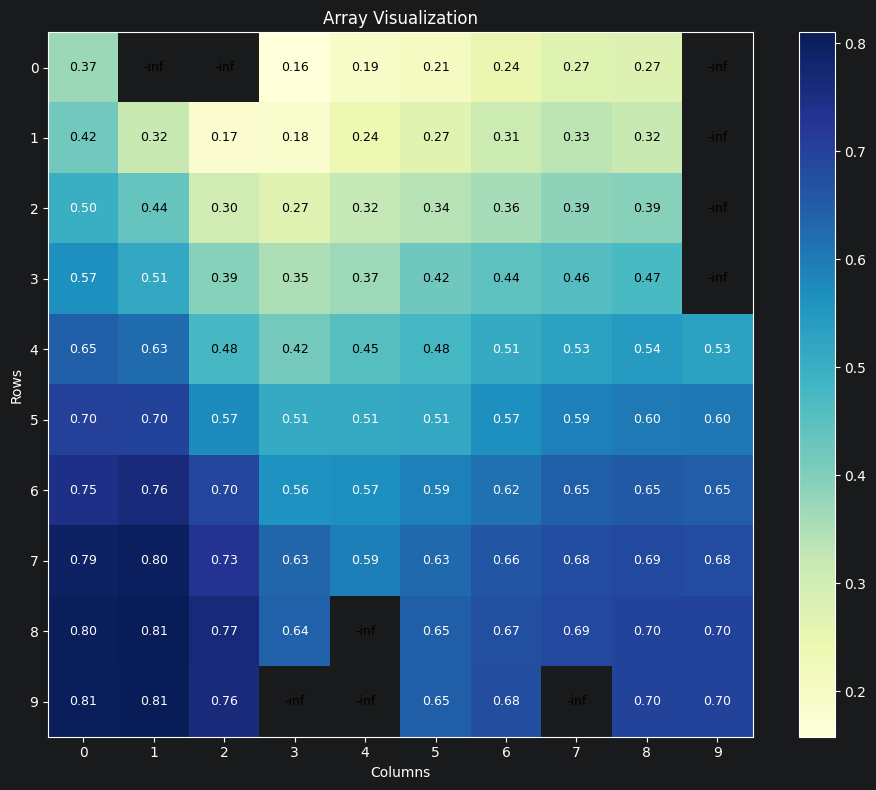

Versatile Candidate: {'coord': array([0.97807229, 0.1358063 ]), 'fitness': np.float64(0.8100908221111891)}
Versatile Candidate: {'coord': array([0.77060471, 0.14184945]), 'fitness': np.float64(0.7597306218994009)}
Versatile Candidate: {'coord': array([1., 1.]), 'fitness': np.float64(0.7)}
Versatile Candidate: {'coord': array([1.        , 0.77169654]), 'fitness': np.float64(0.6754883091956843)}
Versatile Candidate: {'coord': array([0.77377439, 0.99244645]), 'fitness': np.float64(0.6533560091404733)}
Versatile Candidate: {'coord': array([0.55265665, 0.08700221]), 'fitness': np.float64(0.646942808543959)}
Versatile Candidate: {'coord': array([0.9167812 , 0.34925566]), 'fitness': np.float64(0.641942543285322)}
Versatile Candidate: {'coord': array([0.77711598, 0.71231078]), 'fitness': np.float64(0.6163221785815878)}
Versatile Candidate: {'coord': array([0.55311027, 0.99337823]), 'fitness': np.float64(0.5435908878947531)}
Versatile Candidate: {'coord': array([0.63811613, 0.55828704]), 'fitne

In [23]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites

# 1. Initialize
v_me = VersatileMapElites(bins=10)

# 2. Run the illumination
v_me.run_search(ServiceType.QR, slos, rask_gp, ordered_bounds, iterations=1000)
visualize_ndarray(v_me.fitness_table)

# 3. Get 5 solutions that are high-performing but far apart
diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)

# 4. De-normalize for your agent
for sol in diverse_set:
    # real_val = [sol[i] * (ordered_bounds[i][1] - ordered_bounds[i][0]) + ordered_bounds[i][0]
    #             for i in range(2)]
    print(f"Versatile Candidate: {sol}")